# 5. Red Neuronal — Predicting Smartphone Addiction

> ### ⚠ Este notebook corre en **Python 3.9**, no en el 3.12 del resto del episodio
> Es el único entorno de este equipo con TensorFlow. En VS Code hay que seleccionar a mano el
> intérprete `C:\Program Files\Python39\python.exe`. Ahí **no está instalado seaborn**, por lo que
> los gráficos usan matplotlib con el estilo `seaborn-v0_8-whitegrid`. El intercambio de predicciones
> con los otros notebooks es por archivos `.npy`, que son numpy plano y no dependen del entorno.

## Por qué una red, sabiendo que va a rendir menos

Los dos modelos de árboles del episodio quedaron en un empate técnico (XGBoost 0,96478 · LightGBM
0,96422) y su ensamble **no aportó nada**: correlación de rangos de 0,9955 entre sus predicciones
out-of-fold, y en el leaderboard el blend sacó exactamente el mismo score que XGBoost solo.

Cuando dos modelos ven lo mismo, promediarlos no agrega información. La hipótesis de este notebook es
que una **familia de modelo genuinamente distinta** —una red neuronal, que aprende una frontera suave
en vez de cortes axiales— produzca errores decorrelacionados y ahí sí el ensamble tenga de dónde
sacar algo.

**El objetivo de este notebook no es ganarle a XGBoost.** Es medir dos cosas:

1. **Cuánta diversidad** aporta la red (correlación de rangos contra los GBMs).
2. **Si esa diversidad alcanza** para mejorar el ensamble, dado que la red parte con desventaja.

> **Tiempo de ejecución: ~35-45 minutos** en CPU (~10 s por época, 5 folds).

**Métrica:** ROC AUC · **Dataset:** Playground Series S6E8

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # silencia los avisos de oneDNN/CPU de TensorFlow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import QuantileTransformer, OneHotEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
import tensorflow as tf
import keras
from keras import layers
import warnings
warnings.filterwarnings("ignore")

# En 3.9 no hay seaborn: se usa el estilo equivalente que trae matplotlib
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)
plt.rcParams["figure.dpi"] = 100

SEED    = 42
N_FOLDS = 5
keras.utils.set_random_seed(SEED)

print(f"tensorflow {tf.__version__} | keras {keras.__version__}")
print(f"GPU disponible: {bool(tf.config.list_physical_devices('GPU'))}")

tensorflow 2.19.0 | keras 3.9.0
GPU disponible: False


## 1. Carga y Preprocesamiento

In [2]:
train_raw = pd.read_csv("../data/train.csv")
test_raw  = pd.read_csv("../data/test.csv")

TARGET = "addicted_label"

crudas_num = ["age", "daily_screen_time_hours", "weekend_screen_time", "social_media_hours",
              "gaming_hours", "work_study_hours", "sleep_hours", "notifications_per_day",
              "app_opens_per_day"]
crudas_cat = ["gender", "stress_level", "academic_work_impact"]


def agregar_derivadas(df):
    """Identica a la de los notebooks 2, 3 y 4."""
    d = df.copy()
    componentes = ["social_media_hours", "gaming_hours", "work_study_hours"]
    d["otro_uso"]      = d["daily_screen_time_hours"] - d[componentes].sum(axis=1)
    d["ocio_horas"]    = d["social_media_hours"] + d["gaming_hours"]
    d["screen_sleep"]  = d["daily_screen_time_hours"] / d["sleep_hours"]
    d["social_ratio"]  = d["social_media_hours"] / d["daily_screen_time_hours"]
    d["gaming_ratio"]  = d["gaming_hours"] / d["daily_screen_time_hours"]
    d["weekend_ratio"] = d["weekend_screen_time"] / d["daily_screen_time_hours"]
    d["min_per_open"]  = d["daily_screen_time_hours"] * 60 / d["app_opens_per_day"]
    return d.replace([np.inf, -np.inf], np.nan)


derivadas = ["otro_uso", "ocio_horas", "screen_sleep", "social_ratio",
             "gaming_ratio", "weekend_ratio", "min_per_open"]

train = agregar_derivadas(train_raw)
test  = agregar_derivadas(test_raw)
y     = train[TARGET].values.astype("float32")

num_cols = crudas_num + derivadas
features = num_cols + crudas_cat

print(f"Train: {train.shape[0]:,} filas | Test: {test.shape[0]:,} filas")
print(f"Features: {len(num_cols)} numericas + {len(crudas_cat)} categoricas")

Train: 691,369 filas | Test: 296,302 filas
Features: 16 numericas + 3 categoricas


## 2. Preprocesamiento y Arquitectura

A diferencia de los GBMs, la red **no tolera nulos ni categorías en texto**, así que vuelve a hacer
falta el pipeline del notebook 2 — pero con dos cambios pensados para una red:

- **`QuantileTransformer` en vez de `StandardScaler`.** Varias variables son asimétricas y las
  derivadas tienen colas largas. Mapear cada feature a una normal hace que las activaciones arranquen
  en un rango sano y acelera bastante la convergencia.
- **Las categóricas van one-hot y no como embeddings.** Los notebooks 3 y 4 mostraron que aportan
  ~0,004 de importancia entre las tres: gastar parámetros en embeddings para variables inertes no
  tiene sentido.

El pipeline se ajusta **dentro de cada fold**, sólo con los datos de entrenamiento de ese fold.

La arquitectura es un MLP 256→128→64 con `BatchNormalization` (que es lo que le permite entrenar con
learning rate alto) y `Dropout` de 0,2. El early stopping mira **AUC de validación**, que es la
métrica de la competencia, y no la loss.

In [3]:
def construir_preprocesador():
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("qt",  QuantileTransformer(output_distribution="normal",
                                                      n_quantiles=1000, random_state=SEED))]), num_cols),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first"))]), crudas_cat),
    ])


def construir_red(n_inputs):
    modelo = keras.Sequential([
        layers.Input((n_inputs,)),
        layers.Dense(256, use_bias=False), layers.BatchNormalization(),
        layers.Activation("relu"), layers.Dropout(0.2),
        layers.Dense(128, use_bias=False), layers.BatchNormalization(),
        layers.Activation("relu"), layers.Dropout(0.2),
        layers.Dense(64, use_bias=False), layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    modelo.compile(optimizer=keras.optimizers.Adam(2e-3),
                   loss="binary_crossentropy",
                   metrics=[keras.metrics.AUC(name="auc")])
    return modelo


MAX_EPOCHS = 50
BATCH      = 4096

construir_red(len(num_cols) + 5).summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,193 (188.25 KB)

 Trainable params: 47,297 (184.75 KB)

 Non-trainable params: 896 (3.50 KB)

## 3. Validación Cross-Validation

Se usa **el mismo `StratifiedKFold(5, shuffle=True, random_state=42)`** que los notebooks 3 y 4. Es
condición indispensable: sin folds idénticos, las predicciones out-of-fold no serían comparables entre
notebooks y el ensamble de la sección 7 estaría mal calculado.

In [4]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof      = np.zeros(len(train), dtype=np.float32)
test_sum = np.zeros(len(test),  dtype=np.float32)
aucs, epocas, historias = [], [], []

print(f"{'='*62}")
print("CROSS-VALIDATION — Red Neuronal")
print(f"{'='*62}")

for fold, (tr_idx, val_idx) in enumerate(skf.split(train, y), 1):
    # El preprocesador se ajusta solo con el fold de entrenamiento
    pre   = construir_preprocesador()
    X_tr  = pre.fit_transform(train.iloc[tr_idx][features]).astype("float32")
    X_val = pre.transform(train.iloc[val_idx][features]).astype("float32")
    X_te  = pre.transform(test[features]).astype("float32")

    keras.utils.set_random_seed(SEED + fold)
    modelo = construir_red(X_tr.shape[1])
    hist = modelo.fit(
        X_tr, y[tr_idx],
        validation_data=(X_val, y[val_idx]),
        epochs=MAX_EPOCHS, batch_size=BATCH, verbose=0,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=8,
                                          restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5,
                                              patience=4, min_lr=1e-5),
        ],
    )

    p_val         = modelo.predict(X_val, batch_size=8192, verbose=0).ravel()
    oof[val_idx]  = p_val
    test_sum     += modelo.predict(X_te, batch_size=8192, verbose=0).ravel()

    auc = roc_auc_score(y[val_idx], p_val)
    aucs.append(auc)
    epocas.append(len(hist.history["loss"]))
    historias.append(hist.history)
    print(f"  Fold {fold}: AUC = {auc:.5f}  |  epocas = {epocas[-1]}")

test_nn = test_sum / N_FOLDS
cv_mean = np.mean(aucs)

print(f"{'='*62}")
print(f"  Media: {cv_mean:.5f} +/- {np.std(aucs):.5f}")
print(f"  AUC out-of-fold: {roc_auc_score(y, oof):.5f}")
print(f"  Epocas usadas (media): {np.mean(epocas):.0f} de {MAX_EPOCHS}")
print(f"{'='*62}")

CROSS-VALIDATION — Red Neuronal
  Fold 1: AUC = 0.93970  |  epocas = 50
  Fold 2: AUC = 0.94050  |  epocas = 50
  Fold 3: AUC = 0.94134  |  epocas = 50
  Fold 4: AUC = 0.94220  |  epocas = 50
  Fold 5: AUC = 0.94086  |  epocas = 50
  Media: 0.94092 +/- 0.00083
  AUC out-of-fold: 0.94092
  Epocas usadas (media): 50 de 50


## 4. Curvas de Entrenamiento

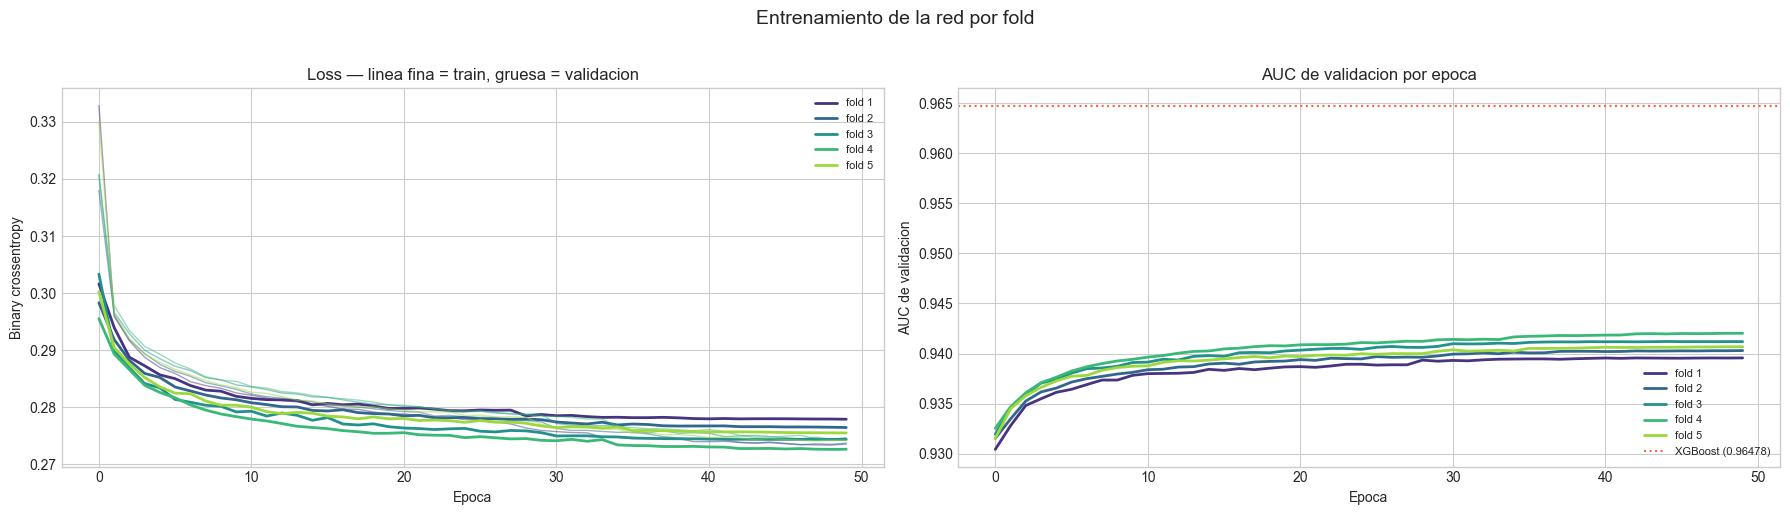

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
colores = plt.cm.viridis(np.linspace(0.15, 0.85, N_FOLDS))

for i, h in enumerate(historias):
    axes[0].plot(h["loss"], color=colores[i], alpha=0.5, lw=1)
    axes[0].plot(h["val_loss"], color=colores[i], lw=2, label=f"fold {i+1}")
    axes[1].plot(h["val_auc"], color=colores[i], lw=2, label=f"fold {i+1}")

axes[0].set_xlabel("Epoca"); axes[0].set_ylabel("Binary crossentropy")
axes[0].set_title("Loss — linea fina = train, gruesa = validacion")
axes[0].legend(fontsize=8)
axes[1].axhline(0.96478, color="tomato", ls=":", lw=1.5, label="XGBoost (0.96478)")
axes[1].set_xlabel("Epoca"); axes[1].set_ylabel("AUC de validacion")
axes[1].set_title("AUC de validacion por epoca")
axes[1].legend(fontsize=8)
plt.suptitle("Entrenamiento de la red por fold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Diagnóstico — Curva ROC y Separación de Probabilidades

AUC out-of-fold: 0.94092


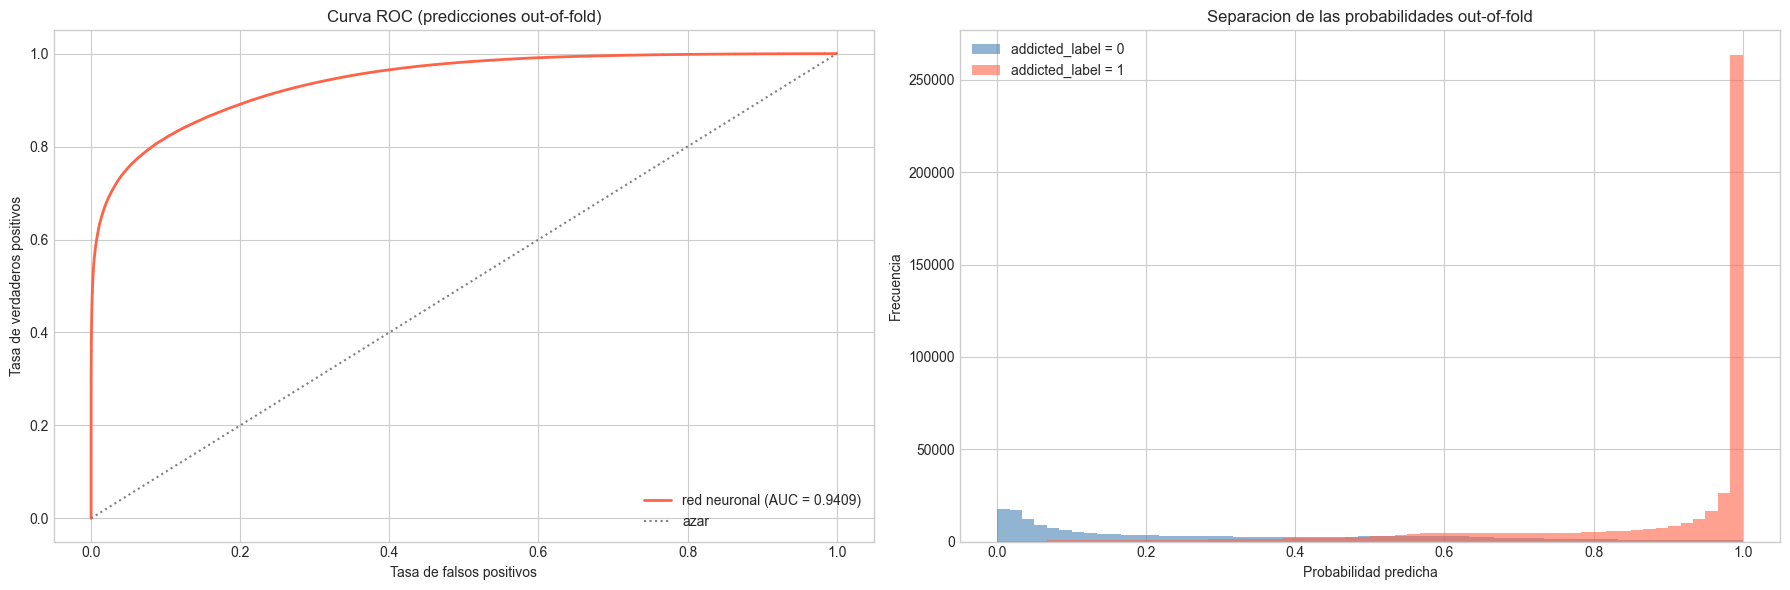

In [6]:
auc_oof = roc_auc_score(y, oof)
print(f"AUC out-of-fold: {auc_oof:.5f}")

fpr, tpr, _ = roc_curve(y, oof)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].plot(fpr, tpr, color="tomato", lw=2, label=f"red neuronal (AUC = {auc_oof:.4f})")
axes[0].plot([0, 1], [0, 1], color="gray", ls=":", lw=1.5, label="azar")
axes[0].set_xlabel("Tasa de falsos positivos")
axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].set_title("Curva ROC (predicciones out-of-fold)")
axes[0].legend(loc="lower right")
for cls, color in [(0, "steelblue"), (1, "tomato")]:
    axes[1].hist(oof[y == cls], bins=60, alpha=0.6, color=color,
                 label=f"addicted_label = {int(cls)}")
axes[1].set_xlabel("Probabilidad predicha")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Separacion de las probabilidades out-of-fold")
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Comparación con los Modelos Previos

In [7]:
AUC_LOGIT = 0.91687   # 2_logit.ipynb
AUC_XGB   = 0.96478   # 3_xgboost.ipynb
AUC_LGBM  = 0.96422   # 4_lightgbm.ipynb

comparativa = pd.DataFrame({
    "modelo": ["Logit", "XGBoost", "LightGBM", "Red neuronal"],
    "familia": ["lineal", "arboles", "arboles", "red neuronal"],
    "CV AUC": [AUC_LOGIT, AUC_XGB, AUC_LGBM, cv_mean],
})
comparativa["delta vs XGBoost"] = (comparativa["CV AUC"] - AUC_XGB).round(5)

print(f"{'='*62}")
print("COMPARATIVA DE MODELOS")
print(f"{'='*62}")
print(comparativa.round(5).to_string(index=False))
print(f"{'='*62}")

COMPARATIVA DE MODELOS
      modelo      familia  CV AUC  delta vs XGBoost
       Logit       lineal 0.91687          -0.04791
     XGBoost      arboles 0.96478           0.00000
    LightGBM      arboles 0.96422          -0.00056
Red neuronal red neuronal 0.94092          -0.02386


## 7. Diversidad y Ensamble

Esta es la sección que justifica el notebook. Se responden las dos preguntas del principio en orden:
primero **cuánta diversidad** aporta la red, y después **si esa diversidad alcanza**.

Un ensamble mejora cuando los modelos se equivocan en filas distintas. Pero hay un segundo requisito,
que suele olvidarse: el modelo que se suma no puede ser *demasiado* peor, porque su error propio pesa
más que lo que aporta su independencia.

Correlacion de rangos entre las predicciones out-of-fold:
              xgboost  lightgbm  red_neuronal
xgboost        1.0000    0.9955        0.9638
lightgbm       0.9955    1.0000        0.9677
red_neuronal   0.9638    0.9677        1.0000

  Cuanto mas baja, mas distinto es lo que ve cada modelo.


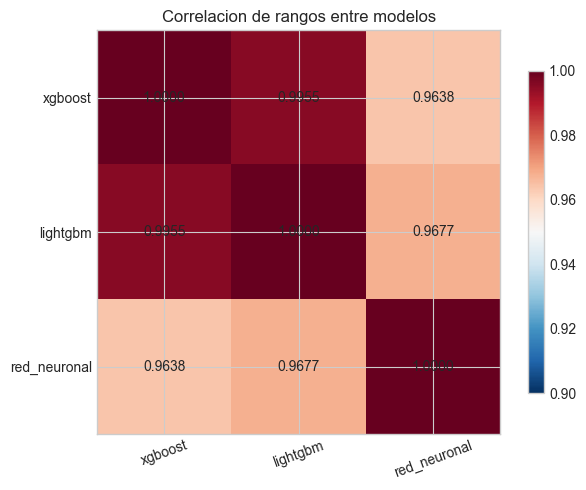

In [8]:
oof_xgb  = np.load("../models/3_xgboost_oof.npy")
test_xgb = np.load("../models/3_xgboost_test.npy")
oof_lgb  = np.load("../models/4_lightgbm_oof.npy")
test_lgb = np.load("../models/4_lightgbm_test.npy")

modelos_oof = {"xgboost": oof_xgb, "lightgbm": oof_lgb, "red_neuronal": oof}
rangos      = {k: rankdata(v) / len(v) for k, v in modelos_oof.items()}

corr = pd.DataFrame(
    [[np.corrcoef(rangos[a], rangos[b])[0, 1] for b in modelos_oof] for a in modelos_oof],
    index=modelos_oof, columns=modelos_oof,
)
print("Correlacion de rangos entre las predicciones out-of-fold:")
print(corr.round(4).to_string())
print("\n  Cuanto mas baja, mas distinto es lo que ve cada modelo.")

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=0.9, vmax=1.0)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=20)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.values[i, j]:.4f}", ha="center", va="center", fontsize=10)
ax.set_title("Correlacion de rangos entre modelos")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

Red neuronal + XGBoost:
 peso_red  AUC_oof
     0.00  0.96478
     0.05  0.96461
     0.10  0.96434
     0.15  0.96396
     0.20  0.96348
     0.25  0.96288
     0.30  0.96217
     0.35  0.96133
     0.40  0.96038
     0.45  0.95930
     0.50  0.95811


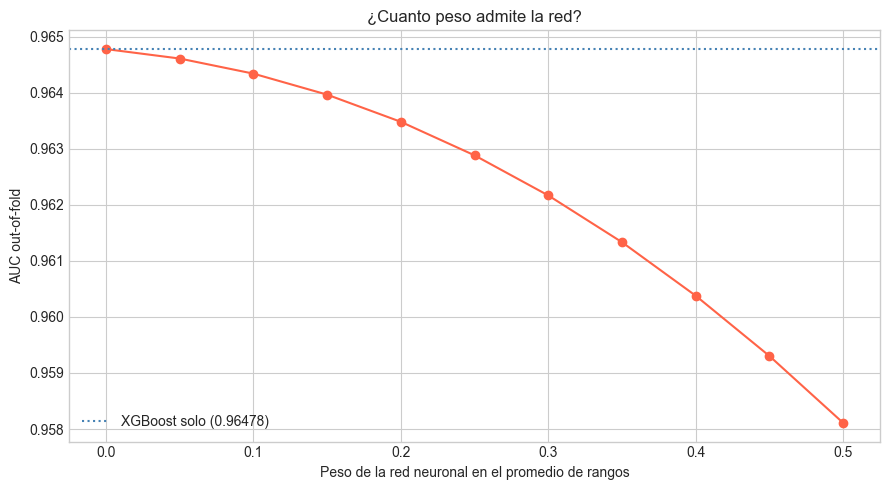

In [9]:
# Barrido de 2 vias: cuanto peso admite la red junto al mejor GBM
filas = []
for w in np.round(np.arange(0.0, 0.55, 0.05), 2):
    filas.append({"peso_red": w,
                  "AUC_oof": roc_auc_score(y, w * rangos["red_neuronal"] +
                                              (1 - w) * rangos["xgboost"])})
barrido = pd.DataFrame(filas)
print("Red neuronal + XGBoost:")
print(barrido.round(5).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(barrido["peso_red"], barrido["AUC_oof"], marker="o", color="tomato")
ax.axhline(AUC_XGB, color="steelblue", ls=":", lw=1.5, label=f"XGBoost solo ({AUC_XGB:.5f})")
ax.set_xlabel("Peso de la red neuronal en el promedio de rangos")
ax.set_ylabel("AUC out-of-fold")
ax.set_title("¿Cuanto peso admite la red?")
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# Busqueda de 3 vias sobre la grilla de pesos (xgb + lgbm + red = 1)
mejor = {"auc": 0.0}
for w_nn in np.round(np.arange(0, 0.55, 0.05), 2):
    for w_lgb in np.round(np.arange(0, 1.01 - w_nn, 0.05), 2):
        w_xgb = round(1 - w_nn - w_lgb, 2)
        mezcla = (w_nn * rangos["red_neuronal"] + w_lgb * rangos["lightgbm"] +
                  w_xgb * rangos["xgboost"])
        auc = roc_auc_score(y, mezcla)
        if auc > mejor["auc"]:
            mejor = {"auc": auc, "w_nn": w_nn, "w_lgb": w_lgb, "w_xgb": w_xgb}

mejor_individual = max(cv_mean, AUC_XGB, AUC_LGBM)
print(f"{'='*62}")
print("MEJOR ENSAMBLE DE 3 MODELOS")
print(f"{'='*62}")
print(f"  pesos -> red: {mejor['w_nn']:.2f} | lightgbm: {mejor['w_lgb']:.2f} | "
      f"xgboost: {mejor['w_xgb']:.2f}")
print(f"  AUC del ensamble:        {mejor['auc']:.5f}")
print(f"  Mejor modelo individual: {mejor_individual:.5f}")
print(f"  Ganancia:                {mejor['auc'] - mejor_individual:+.5f}")
print(f"{'='*62}")
if mejor["w_nn"] == 0:
    print("\n  La busqueda le asigno peso CERO a la red: su desventaja pesa mas que su diversidad.")

MEJOR ENSAMBLE DE 3 MODELOS
  pesos -> red: 0.00 | lightgbm: 0.30 | xgboost: 0.70
  AUC del ensamble:        0.96494
  Mejor modelo individual: 0.96478
  Ganancia:                +0.00016

  La busqueda le asigno peso CERO a la red: su desventaja pesa mas que su diversidad.


## 8. Predicción sobre Test y Submission

In [11]:
submission = pd.DataFrame({"id": test["id"], TARGET: test_nn})
submission.to_csv("../submissions/5_red_neuronal_submission.csv", index=False)

np.save("../models/5_red_neuronal_oof.npy",  oof)
np.save("../models/5_red_neuronal_test.npy", test_nn)

sample = pd.read_csv("../data/sample_submission.csv")
assert list(submission.columns) == list(sample.columns), "columnas no coinciden"
assert len(submission) == len(sample), "cantidad de filas no coincide"
assert (submission["id"].values == sample["id"].values).all(), "ids no alineados"
assert submission[TARGET].between(0, 1).all(), "valores fuera de [0, 1]"
assert submission[TARGET].notna().all(), "hay nulos"

print(f"Submission escrita: ../submissions/5_red_neuronal_submission.csv ({len(submission):,} filas)")
print(f"  proba media: {test_nn.mean():.4f}  (tasa base train: {y.mean():.4f})")
print("  Chequeos OK.")

# El ensamble solo se guarda si efectivamente mejora al mejor modelo individual
if mejor["auc"] > mejor_individual:
    mezcla_test = (mejor["w_nn"]  * (rankdata(test_nn)  / len(test_nn)) +
                   mejor["w_lgb"] * (rankdata(test_lgb) / len(test_lgb)) +
                   mejor["w_xgb"] * (rankdata(test_xgb) / len(test_xgb)))
    pd.DataFrame({"id": test["id"], TARGET: mezcla_test}).to_csv(
        "../submissions/5_ensamble_3_submission.csv", index=False)
    print("\nEnsamble escrito: ../submissions/5_ensamble_3_submission.csv")
else:
    print("\nNo se escribe submission de ensamble: no supera al mejor modelo individual.")

Submission escrita: ../submissions/5_red_neuronal_submission.csv (296,302 filas)
  proba media: 0.7095  (tasa base train: 0.7094)
  Chequeos OK.

Ensamble escrito: ../submissions/5_ensamble_3_submission.csv


## 9. Envío a Kaggle vía API

La submission de la red **por sí sola no va a competir** con el 0,96634 que ya tiene XGBoost en el
leaderboard. Enviarla sólo tiene sentido si se quiere dejar registrado el score público del
experimento, y consume uno de los envíos diarios. Las celdas están sin ejecutar.

In [12]:
COMPETITION = "playground-series-s6e8"
FILE        = "../submissions/5_red_neuronal_submission.csv"
MSG         = f"Red neuronal Keras - experimento de diversidad - CV AUC={cv_mean:.5f}"

!kaggle competitions submit -c {COMPETITION} -f "{FILE}" -m "{MSG}"

Successfully submitted to Predicting Smartphone Addiction



  0%|          | 0.00/5.22M [00:00<?, ?B/s]
  4%|▎         | 192k/5.22M [00:00<00:02, 1.85MB/s]
 11%|█         | 592k/5.22M [00:00<00:04, 1.21MB/s]
 14%|█▍        | 736k/5.22M [00:00<00:05, 820kB/s] 
 77%|███████▋  | 4.02M/5.22M [00:00<00:00, 6.70MB/s]
100%|██████████| 5.22M/5.22M [00:01<00:00, 2.93MB/s]


In [13]:
!kaggle competitions submissions -c playground-series-s6e8

fileName                         date                        description                                                      status                     publicScore  privateScore  
-------------------------------  --------------------------  ---------------------------------------------------------------  -------------------------  -----------  ------------  
5_red_neuronal_submission.csv    2026-08-15 23:32:30.953000  Red neuronal Keras - experimento de diversidad - CV AUC=0.94092  SubmissionStatus.PENDING                              
5_red_neuronal_submission.csv    2026-08-15 23:32:24.837000  Red neuronal Keras - experimento de diversidad - CV AUC=0.94092  SubmissionStatus.PENDING                              
4_lgbm_xgb_blend_submission.csv  2026-08-15 21:31:28         LGBM+XGB rank blend w=0.30 - OOF AUC=0.96494                     SubmissionStatus.COMPLETE  0.96634                    
3_xgboost_submission.csv         2026-08-11 00:30:06.843000  XGBoost - cat nativas + NaN nativo

## 10. Conclusiones

- **CV AUC = 0,94092 ± 0,00083** (0,94270 en el leaderboard público). Queda **0,024 por debajo** del
  XGBoost, en línea con lo que anticipaba la medición preliminar de un fold.
- **La hipótesis de diversidad se confirmó.** Correlación de rangos de **0,9638 contra XGBoost** y
  0,9677 contra LightGBM, frente al **0,9955** entre los dos árboles entre sí. La red efectivamente ve
  el problema de otra manera: es lo que se buscaba al elegir una familia de modelo distinta.
- **Y aun así no aporta nada.** El barrido de pesos es monótonamente decreciente **desde el primer
  punto** — con apenas 0,05 de peso el AUC ya cae de 0,96478 a 0,96461. La búsqueda de tres vías le
  asignó **peso exactamente cero**: el mejor ensamble resultó 0,30 LightGBM + 0,70 XGBoost = 0,96494,
  idéntico al que ya había encontrado `4_lightgbm.ipynb` sin la red.
- **La lección, ahora cuantificada**: la diversidad es condición **necesaria pero no suficiente**. Con
  0,024 de desventaja, ninguna cantidad de independencia alcanza para compensar el error propio del
  modelo débil. Como regla práctica de este dataset, el candidato a ensamblar tendría que estar dentro
  de ~0,01 del líder.
- **Caveat honesto sobre el resultado**: los cinco folds usaron **50 de 50 épocas** — el early stopping
  nunca llegó a activarse. La red seguía mejorando cuando se le terminó el presupuesto, así que
  0,94092 es una **cota inferior y no su techo**. No invalida la conclusión del ensamble (haría falta
  cerrar 0,024, no unas décimas de milésima), pero sí impide afirmar que las redes saturan acá: para
  eso habría que correrla con más épocas.
- **Por qué pierde, más allá del presupuesto**: los árboles construyen escalones sobre ejes concretos
  (`daily_screen_time > 7,2`) mientras que una red aproxima esos cortes con funciones suaves y tiende
  a soluciones de baja frecuencia. El EDA ya mostraba que la señal vive en umbrales sobre pocas
  variables. La vía documentada para achicar esa brecha no es más profundidad sino cambiarle el sesgo
  inductivo — por ejemplo con embeddings de variables numéricas por binning, que le entregan los
  cortes por eje ya construidos.